In [1]:
!python3 -m pip install --upgrade pip
!python3 -m pip install konlpy # Python 3.x
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) # MeCab 설치하기
!sudo apt-get install -y fonts-nanum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.4 MB/s eta 0:00:00 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 25.1.1
    Uninstalling pip-25.1.1:
      Successfully uninstalled pip-25.1.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 43.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 69.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]
Installing automake (A dependency for mecab-ko)
Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble InRelease [256 kB]
Get:3 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [2071 kB]
Get:4 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [3673 kB]
Get:5 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1504 kB]
Get:6 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Packages [34.2 kB

In [2]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.0 MB/s  0:00:00 eta 0:00:01


In [6]:
!sudo apt update
!sudo apt install openjdk-17-jdk -y
!echo 'export JAVA_HOME=$(dirname $(dirname $(readlink -f $(which java))))' >> ~/.bashrc
!source ~/.bashrc

!pip install konlpy

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
131 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  adwaita-icon-theme at-spi2-common at-spi2-core bsdutils ca-certificates-java
  dbus dbus-bin dbus-daemon dbus-session-bus-common dbus-system-bus-common
  dbus-user-session dconf-gsettings-backend dconf-service dmsetup
  fonts-dejavu-core fonts-dejavu-extra fonts-dejavu-mono
  gir1.2-girepository-2.0 gir1.2-glib-2.0 gsettings-desktop-schemas
  gtk-update-icon-cache hicolor-icon-theme humanity-icon-theme java-common
  libargon2-1 

In [7]:
!pip install --upgrade nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 27.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nltk]1/2 [nltk]


In [8]:
import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
from torch.utils.data import TensorDataset, DataLoader
import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

torch.manual_seed(1)

data = pd.read_csv('~/data/ChatbotData.csv')

2.7.1+cu118


### **Transfomer model**

In [25]:
VOCAB_SIZE = 8000
BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#########################################################
################### transformer model ###################3
#########################################################
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table
print("슝=3")

def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

print("슝=3")

class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

print("슝=3")


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

print("슝=3")

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)
print("슝=3")


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

print("슝=3")


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

print("슝=3")

import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        # if shared_fc:
        #     # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
        #     self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")


# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=False,
    shared_emb=True)

transformer = transformer.to(device)

d_model = 512

print("슝=3")
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=500): # 4000
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

print("슝=3")

# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

print("슝=3")


def train_step(src, tgt, model, optimizer):
    model.train()  # 모델을 training 모드로 전환
    optimizer.zero_grad()

    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # loss 계산
    loss = loss_function(gold, predictions)

    # 역전파 수행 및 파라미터 업데이트
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

print("슝=3")
import torch
import matplotlib.pyplot as plt


def train_model(transformer,
                train_dataloader,
                valid_dataloader,
                optimizer,
                EPOCHS):

    # train / validation loss 저장
    train_loss_history = []
    valid_loss_history = []

    for epoch in range(EPOCHS):

        # =========================
        # Train
        # =========================
        transformer.train()

        train_total_loss = 0.0

        for src, tgt in train_dataloader:
            src = src.to(device)
            tgt = tgt.to(device)
            loss, enc_attns, dec_attns, dec_enc_attns = train_step(
                src,
                tgt,
                transformer,
                optimizer
            )

            train_total_loss += loss.item()

        train_epoch_loss = train_total_loss / len(train_dataloader)

        train_loss_history.append(train_epoch_loss)

        # =========================
        # Validation
        # =========================
        transformer.eval()

        valid_total_loss = 0.0

        with torch.no_grad():

            for src, tgt in valid_dataloader:
                src = src.to(device)
                tgt = tgt.to(device)
                # mask 생성
                enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(src, tgt[:, :-1])

                # 예측
                predictions, _, _, _ = transformer(
                    src,
                    tgt[:, :-1],
                    enc_padding_mask,
                    combined_mask,
                    dec_padding_mask
                )

                # loss 계산
                loss = loss_function(
                    tgt[:, 1:],
                    predictions
                )

                valid_total_loss += loss.item()

        valid_epoch_loss = valid_total_loss / len(valid_dataloader)

        valid_loss_history.append(valid_epoch_loss)

        # =========================
        # Epoch 결과 출력
        # =========================
        print(
            f"[Epoch {epoch+1}/{EPOCHS}] "
            f"Train Loss: {train_epoch_loss:.4f} | "
            f"Valid Loss: {valid_epoch_loss:.4f}"
        )

    return train_loss_history, valid_loss_history


슝=3
슝=3
슝=3
슝=3
슝=3
슝=3
슝=3
슝=3
슝=3
슝=3
슝=3
슝=3
슝=3
슝=3


In [79]:

####################### evalutation #######################################

def beam_search_decoder(prob, beam_size):
    sequences = [[[], 1.0]]  # 생성된 문장과 점수를 저장

    for tok in prob:
        all_candidates = []

        for seq, score in sequences:
            for idx, p in enumerate(tok): # 각 단어의 확률을 총점에 누적 곱
                candidate = [seq + [idx], score * -math.log(-(p-1))]
                all_candidates.append(candidate)

        ordered = sorted(all_candidates,
                         key=lambda tup:tup[1],
                         reverse=True) # 총점 순 정렬
        sequences = ordered[:beam_size] # Beam Size에 해당하는 문장만 저장

    return sequences



import torch
import torch.nn.functional as F

def calc_prob(src_ids, tgt_ids, model):
    # 마스크 생성 (PyTorch 버전)
    enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(src_ids, tgt_ids)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src_ids,
        tgt_ids,
        enc_padding_mask,
        combined_mask,
        dec_padding_mask
    )

    # 마지막 차원에 대해 softmax 적용하여 확률값 계산
    return F.softmax(predictions, dim=-1)

print("슝=3")


import numpy as np
import torch

def beam_search_decoder(sentence,
                        src_len,
                        tgt_len,
                        model,
                        src_tokenizer,
                        tgt_tokenizer,
                        beam_size):
    # 입력 문장을 토큰화
    tokens = src_tokenizer.encode_as_ids(sentence)

    # src_in: [1, src_len] 크기의 텐서로 padding (0: 패딩 토큰)
    padded = np.zeros((1, src_len), dtype=np.int64)
    padded[0, :len(tokens)] = tokens
    src_in = torch.tensor(padded, dtype=torch.long, device=device)

    # beam search용 캐시 배열들
    pred_cache = np.zeros((beam_size * beam_size, tgt_len), dtype=np.int64)
    pred_tmp = np.zeros((beam_size, tgt_len), dtype=np.int64)

    eos_flag = np.zeros((beam_size,), dtype=np.int64)  # EOS를 만난 branch 표시 (EOS: -1)
    scores = np.ones((beam_size,), dtype=np.float32)     # 각 branch의 score (확률 곱)

    # 디코더 첫 입력은 BOS 토큰
    pred_tmp[:, 0] = tgt_tokenizer.bos_id()

    # 초기 디코더 입력 (branch 0의 첫 토큰) -> shape: [1, 1]
    dec_in = torch.tensor(pred_tmp[0, :1], dtype=torch.long, device=device).unsqueeze(0)
    # calc_prob()는 softmax를 적용한 확률 텐서를 반환함
    prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

    # seq_pos: 디코더 시퀀스 위치
    for seq_pos in range(1, tgt_len):
        score_cache = np.ones((beam_size * beam_size,), dtype=np.float32)

        # 각 beam branch에 대해 캐시 초기화
        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            score_cache[cache_pos:cache_pos+beam_size] = scores[branch_idx]
            pred_cache[cache_pos:cache_pos+beam_size, :seq_pos] = pred_tmp[branch_idx, :seq_pos]

        # 각 beam branch에 대해 후보 확률 계산 및 캐시 업데이트
        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            if seq_pos != 1:
                # 해당 branch의 현재까지의 시퀀스를 디코더 입력으로 변환
                dec_in_np = pred_cache[branch_idx, :seq_pos]
                dec_in = torch.tensor(dec_in_np, dtype=torch.long, device=device).unsqueeze(0)
                prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

            # 각 branch 내에서 beam_size만큼의 후보 토큰을 선택
            for beam_idx in range(beam_size):
                max_idx = np.argmax(prob)
                # 후보 branch의 score 업데이트 (곱셈으로 누적)
                score_cache[cache_pos + beam_idx] *= prob[max_idx]
                pred_cache[cache_pos + beam_idx, seq_pos] = max_idx
                # 이미 선택된 토큰은 다시 선택되지 않도록 -1로 마킹
                prob[max_idx] = -1

        # 각 beam branch에서 최고 score를 가진 후보를 선택
        for beam_idx in range(beam_size):
            if eos_flag[beam_idx] == -1:
                continue
            max_idx = np.argmax(score_cache)
            prediction = pred_cache[max_idx, :seq_pos+1].copy()
            pred_tmp[beam_idx, :seq_pos+1] = prediction
            scores[beam_idx] = score_cache[max_idx]
            score_cache[max_idx] = -1  # 해당 후보 제거

            # 만약 EOS 토큰이면 해당 branch는 종료 표시 (-1)
            if prediction[-1] == tgt_tokenizer.eos_id():
                eos_flag[beam_idx] = -1

    # 각 branch의 예측 시퀀스에서 EOS 토큰 이전까지만 추출하여 결과 반환
    pred = []
    for long_pred in pred_tmp:
        eos_token = tgt_tokenizer.eos_id()
        # EOS 토큰이 없는 경우, 전체 시퀀스를 사용하도록 처리할 수 있음
        try:
            eos_idx = list(long_pred).index(eos_token)
        except ValueError:
            eos_idx = tgt_len - 1
        short_pred = long_pred[:eos_idx+1]
        pred.append(short_pred.tolist())

    return pred

def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()
print("슝=3")
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)  # smoothing_function 적용

def eval_bleu_single(model, src_sentence, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    src_tokens = src_tokenizer.encode_as_ids(src_sentence)
    tgt_tokens = tgt_tokenizer.encode_as_ids(tgt_sentence)

    if (len(src_tokens) > ENCODER_MAX_LEN): return None
    if (len(tgt_tokens) > DECODER_MAX_LEN): return None

    reference = tgt_sentence.split()
    candidate = translate(src_tokens, model, src_tokenizer, tgt_tokenizer).split()

    score = sentence_bleu([reference], candidate,
                          smoothing_function=SmoothingFunction().method1)

    if verbose:
        print("Source Sentence: ", src_sentence)
        print("Model Prediction: ", candidate)
        print("Real: ", reference)
        print("Score: %lf\n" % score)

    return score

print('슝=3')
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                            candidate,
                            weights=weights,
                            smoothing_function=SmoothingFunction().method1)

print('슝=3')

def beam_bleu(reference, ids, tokenizer):
    # 기준 문장을 토큰화
    reference_tokens = reference.split()

    total_score = 0.0
    num_candidates = len(ids)
    if num_candidates == 0:
        return 0.0

    for candidate_ids in ids:
        # 후보 문장을 디코딩 후 토큰화
        candidate_sentence = tokenizer.decode_ids(candidate_ids)
        candidate_tokens = candidate_sentence.split()

        score = calculate_bleu(reference_tokens, candidate_tokens)

        print(f"Reference: {reference_tokens}")
        print(f"Candidate: {candidate_tokens}")
        print(f"BLEU: {score}")

        total_score += score

    return total_score / num_candidates

print("슝=3")
import torch
import torch.nn.functional as F

def translate(tokens, model, src_tokenizer, tgt_tokenizer):
    # tokens: 입력 토큰 리스트
    # MAX_LEN: 최대 길이 (전역 변수 혹은 상수)
    # device: 모델과 데이터가 위치한 디바이스

    # tokens 길이가 MAX_LEN보다 크면 자르고, 작으면 0으로 패딩
    if len(tokens) > MAX_LEN:
        tokens = tokens[:MAX_LEN]
    else:
        tokens = tokens + [0] * (MAX_LEN - len(tokens))

    # 배치 차원을 추가하여 텐서로 변환 (shape: [1, MAX_LEN])
    padded_tokens = torch.tensor([tokens], dtype=torch.long, device=device)

    ids = []
    # 디코더의 첫 입력은 BOS 토큰 (배치 차원 추가)
    output = torch.tensor([[tgt_tokenizer.bos_id()]], dtype=torch.long, device=device)

    for i in range(MAX_LEN):
        # generate_masks는 padded_tokens와 현재 output으로부터 마스크들을 생성합니다.
        enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(padded_tokens, output)

        # 모델 예측: predictions shape: [batch, seq_len, num_classes]
        predictions, _, _, _ = model(padded_tokens, output, enc_padding_mask, combined_mask, dec_padding_mask)

        # 마지막 시퀀스 위치의 예측값을 소프트맥스 후 argmax로 선택
        predicted_id = predictions[0, -1].softmax(dim=-1).argmax(dim=-1).item()

        # EOS 토큰에 도달하면 현재까지의 예측 토큰 ids를 디코딩 후 반환
        if tgt_tokenizer.eos_id() == predicted_id:
            result = tgt_tokenizer.decode_ids(ids)
            return result

        ids.append(predicted_id)
        # 현재 output에 새로운 예측 토큰을 연결 (dim=1)
        new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
        output = torch.cat([output, new_token], dim=1)

    result = tgt_tokenizer.decode_ids(ids)
    return result

print("슝=3")
def eval_bleu(model, src_sentences, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    total_score = 0.0
    sample_size = len(src_sentences)

    for idx in tqdm(range(sample_size)):
        score = eval_bleu_single(model, src_sentences[idx], tgt_sentence[idx], src_tokenizer, tgt_tokenizer, verbose)
        if not score: continue

        total_score += score

    print("Num of Sample:", sample_size)
    print("Total Score:", total_score / sample_size)

print("슝=3")

슝=3
슝=3
슝=3
슝=3
슝=3
슝=3
슝=3


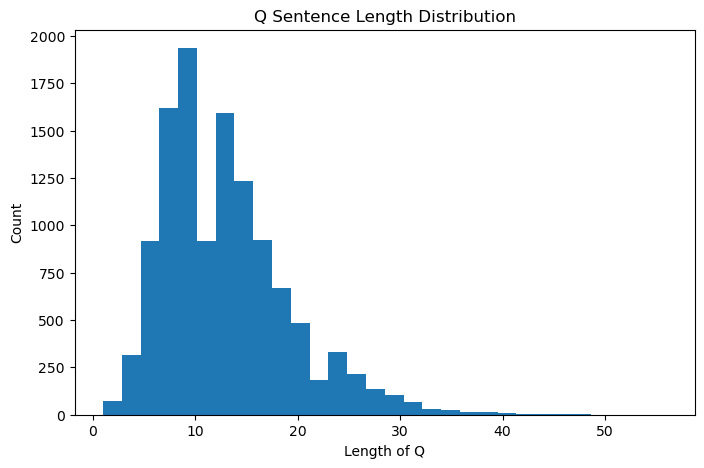

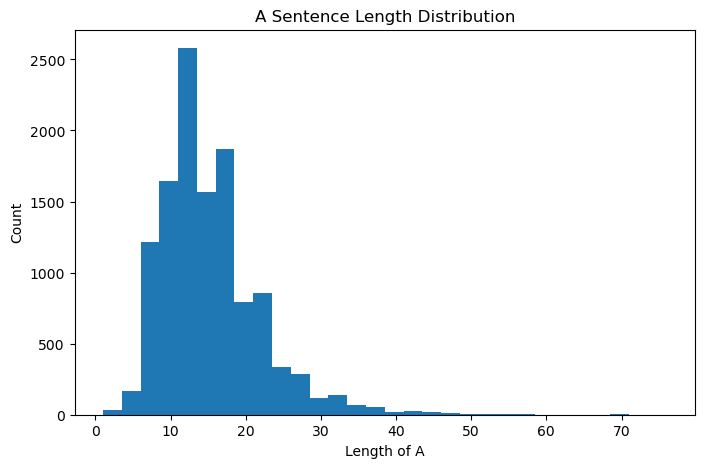

In [11]:
def preprocess_ko(sentence):
    sentence = sentence.strip()
    sentence = re.sub(
        r"([?.!,])",
        r" \1 ",
        sentence
    )
    sentence = re.sub(
        r'[" "]+',
        " ",
        sentence
    )
    sentence = re.sub(
        r"[^가-힣ㄱ-ㅎㅏ-ㅣ0-9?.!,]+",
        " ",
        sentence
    )
    sentence = sentence.strip()
    return sentence

import matplotlib.pyplot as plt

# Q와 A 문장의 길이 계산
q_lengths = data['Q'].apply(len)
a_lengths = data['A'].apply(len)

# Q 문장 길이 histogram
plt.figure(figsize=(8, 5))
plt.hist(q_lengths, bins=30)
plt.xlabel('Length of Q')
plt.ylabel('Count')
plt.title('Q Sentence Length Distribution')
plt.show()

# A 문장 길이 histogram
plt.figure(figsize=(8, 5))
plt.hist(a_lengths, bins=30)
plt.xlabel('Length of A')
plt.ylabel('Count')
plt.title('A Sentence Length Distribution')
plt.show()



In [12]:

from sklearn.model_selection import train_test_split
train_data, temp_data = train_test_split(data, test_size=0.2)

valid_data, test_data = train_test_split(temp_data, test_size=0.5)
# 데이터 개수 확인
print("전체 데이터 개수 :", len(data))
print("Train 데이터 개수 :", len(train_data))
print("Valid 데이터 개수 :", len(valid_data))
print("Test 데이터 개수 :", len(test_data))



### 토큰화
def generate_tokenizer2(corpus,
                       vocab_size,
                       lang="qa_chatbot",
                       pad_id=0,   # pad token의 일련번호
                       bos_id=1,  # 문장의 시작을 의미하는 bos token(<s>)의 일련번호
                       eos_id=2,  # 문장의 끝을 의미하는 eos token(</s>)의 일련번호
                       unk_id=3):   # unk token의 일련번호
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
        for row in corpus: f.write(str(row) + '\n')

    import sentencepiece as spm
    spm.SentencePieceTrainer.Train(
        '--input=./%s --model_prefix=%s --vocab_size=%d'\
        % (file, model, vocab_size) + \
        '--pad_id=%d --bos_id=%d --eos_id=%d --unk_id=%d'\
        % (pad_id, bos_id, eos_id, unk_id)
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load('%s.model' % model)

    return tokenizer

print("슝=3")


# VOCAB_SIZE = 8000
tokenizer = generate_tokenizer2(list(train_data['Q']) + list(train_data['A']), VOCAB_SIZE, 'qa_chatbot')
tokenizer.set_encode_extra_options("bos:eos")  # 문장 양 끝에 <s> , </s> 추가




# 문장들을 token id 형태로 변환하여 corpus 생성하는 함수
def make_corpus(sentences, tokenizer):

    # 최종 tokenized 문장들을 저장할 리스트
    corpus = []

    # tqdm:
    # 반복문의 진행상황(progress bar) 표시
    for sentence in tqdm(sentences):

        # 문장을 tokenizer로 토큰화한 뒤
        # 각 토큰을 정수 id로 변환
        #
        # 예:
        # "안녕하세요"
        # -> [45, 132, 78]
        tokens = tokenizer.encode_as_ids(sentence)

        # 변환된 token id 리스트를 corpus에 추가
        corpus.append(tokens)

    # 전체 tokenized corpus 반환
    return corpus


# 실행 확인용 출력
print('슝=3')

q_corpus = make_corpus(train_data['Q'], tokenizer)
a_corpus = make_corpus(train_data['A'], tokenizer)

print(train_data['Q'].iloc[0])
print(q_corpus[0])
print('\n')
print(train_data['A'].iloc[0])
print(a_corpus[0])

MAX_LEN = 50

def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []

    for seq in sequences:
        # 초과 길이는 자르고
        if len(seq) > max_len:
            seq = seq[:max_len]
        # 부족한 길이는 pad_value로 채우기
        else:
            seq = seq + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    # 최종적으로 torch.Tensor로 변환 (shape: [batch_size, max_len])
    return torch.tensor(padded_sequences, dtype=torch.long)

# Q 문장의 token 길이
q_token_lengths = data['Q'].apply(
    lambda x: len(tokenizer.encode_as_ids(x))
)

# A 문장의 token 길이
a_token_lengths = data['A'].apply(
    lambda x: len(tokenizer.encode_as_ids(x))
)

# token 길이 기준 95 percentile
ENCODER_MAX_LEN = int(np.percentile(q_token_lengths, 95))
DECODER_MAX_LEN = int(np.percentile(a_token_lengths, 95))

print(ENCODER_MAX_LEN)
print(DECODER_MAX_LEN)


전체 데이터 개수 : 11823
Train 데이터 개수 : 9458
Valid 데이터 개수 : 1182
Test 데이터 개수 : 1183
슝=3
슝=3


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././qa_chatbot_corpus.txt --model_prefix=qa_chatbot_spm --vocab_size=8000--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././qa_chatbot_corpus.txt
  input_format: 
  model_prefix: qa_chatbot_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1

  0%|          | 0/9458 [00:00<?, ?it/s]

  0%|          | 0/9458 [00:00<?, ?it/s]

환승당했다는 여자입니다.
[1, 985, 1743, 6842, 128, 258, 0, 2]


사랑의 예의가 없는 사람이네요.
[1, 37, 21, 490, 6, 161, 48, 19, 0, 2]
13
14



# **Data Augmentation Methods**

| Method | Description |
|---|---|
| Lexical Substitution | 단어를 유사 단어로 치환 |
| TF-IDF Based | TF-IDF 중요 단어 기반 치환 |
| Embedding Based | Word2Vec/GloVe 유사도 기반 치환 |
| Original | 원본 데이터만 사용 |





### **(1) Lexical Substitution using KSS**

In [15]:
!pip install kss
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.1 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gensim]2m2/3 [gensim]


In [16]:
# ============================================
# KSS 기반 한국어 Data Augmentation
# Lexical Substitution
# ============================================

# 설치 필요 시
# !pip install kss
# !pip install gensim
# !pip install konlpy

import random
import pandas as pd

from tqdm import tqdm
from konlpy.tag import Okt
from gensim.models import Word2Vec

import kss


# ============================================
# 1. 형태소 분석기
# ============================================

okt = Okt()


# ============================================
# 2. 한국어 토큰화 함수
# ============================================

def tokenize_ko(sentence):

    # 형태소 단위 분리
    tokens = okt.morphs(sentence)

    return tokens


# ============================================
# 3. Word2Vec 학습용 corpus 생성
# ============================================

tokenized_sentences = []

for sentence in train_data['Q']:
    tokenized_sentences.append(tokenize_ko(sentence))

for sentence in train_data['A']:
    tokenized_sentences.append(tokenize_ko(sentence))


# ============================================
# 4. Word2Vec 학습
# ============================================

w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)


# ============================================
# 5. KSS + Lexical Substitution
# ============================================

def lexical_substitution(sentence, wv):

    # KSS 문장 정리
    sentence = kss.normalize(sentence)

    # 형태소 토큰화
    tokens = tokenize_ko(sentence)

    # embedding vocab 안에 있는 단어만 사용
    valid_tokens = [
        tok for tok in tokens
        if tok in wv
    ]

    # 치환 가능한 단어 없으면 원문 반환
    if len(valid_tokens) == 0:
        return sentence

    # 랜덤 단어 선택
    selected_token = random.choice(valid_tokens)

    try:
        # 가장 유사한 단어 추출
        similar_word = wv.most_similar(
            selected_token,
            topn=1
        )[0][0]

    except:
        return sentence

    # 단어 1개만 교체
    new_sentence = sentence.replace(
        selected_token,
        similar_word,
        1
    )

    # KSS 후처리
    new_sentence = kss.normalize(new_sentence)

    return new_sentence


# ============================================
# 6. Data Augmentation
# ============================================

AUG_REPEAT = 3

augmented_q_kss = []
augmented_a_kss = []

for q, a in tqdm(
    zip(train_data['Q'], train_data['A']),
    total=len(train_data)
):

    # 원본 pair 추가
    augmented_q_kss.append(q)
    augmented_a_kss.append(a)

    # augmentation 반복
    for _ in range(AUG_REPEAT):

        new_q = lexical_substitution(
            q,
            w2v_model.wv
        )

        augmented_q_kss.append(new_q)

        # 답변은 유지
        augmented_a_kss.append(a)


# ============================================
# 7. DataFrame 생성
# ============================================

augmented_data_kss = pd.DataFrame({
    'Q': augmented_q_kss,
    'A': augmented_a_kss
})


# ============================================
# 8. 결과 확인
# ============================================

print("원본 데이터 개수 :", len(train_data))
print("증강 데이터 개수 :", len(augmented_data_kss))

print("\n===== 증강 예시 =====")

for i in range(5):

    print("원본 Q :", augmented_q_kss[i*2])
    print("증강 Q :", augmented_q_kss[i*2+1])
    print()

100%|██████████| 9458/9458 [01:08<00:00, 139.07it/s]

원본 데이터 개수 : 9458
증강 데이터 개수 : 37832

===== 증강 예시 =====
원본 Q : 환승당했다는 여자입니다.
증강 Q : 환승당했다는 여자입니다일

원본 Q : 환승생긴다고 여자입니다.
증강 Q : 환승당했다는 여자정말.

원본 Q : 친구들이랑 가기 좋은 곳
증강 Q : 친구들이랑 가기 좋은 날

원본 Q : 친구들이랑 가기 좋은 날
증강 Q : 친구들이랑 가기 죠 곳

원본 Q : 나 좀 내버려 두면 좋겠어
증강 Q : 나 혼자 내버려 두면 좋겠어



- kss 를 이용해서 증강했는데, 증강이 잘 된 문장도 있고 안된 문장도 있다
- 잘된 예 )    원본 Q : 나 좀 내버려 두면 좋겠어
              증강 Q : 나 혼자 내버려 두면 좋겠어
- 이상한 예 )  원본 Q : 친구들이랑 가기 좋은 날
              증강 Q : 친구들이랑 가기 죠 곳

In [27]:
enc_corpus_kss = make_corpus(augmented_q_kss, tokenizer)
dec_corpus_kss = make_corpus(augmented_a_kss, tokenizer)

# # token 길이 계산
# enc_lengths = [len(seq) for seq in enc_corpus]
# dec_lengths = [len(seq) for seq in dec_corpus]

# # 95 percentile
# ENCODER_MAX_LEN = int(np.percentile(enc_lengths, 95))
# DECODER_MAX_LEN = int(np.percentile(dec_lengths, 95))

enc_ndarray_kss = pad_sequences_custom(enc_corpus_kss, max_len=ENCODER_MAX_LEN, pad_value=0)
dec_ndarray_kss = pad_sequences_custom(dec_corpus_kss, max_len=DECODER_MAX_LEN, pad_value=0)

print(enc_ndarray_kss.shape)  # 예) [batch_size, 50]
print(dec_ndarray_kss.shape)  # 예) [batch_size, 50]
print("슝=3")

# ============================================
# Train Tensor
# ============================================

train_enc_tensor_kss = torch.LongTensor(
    enc_ndarray_kss
)

train_dec_tensor_kss = torch.LongTensor(
    dec_ndarray_kss
)


# ============================================
# Train Dataset
# ============================================

train_dataset_kss = TensorDataset(
    train_enc_tensor_kss,
    train_dec_tensor_kss
)


# ============================================
# Train DataLoader
# ============================================

train_dataloader_kss = DataLoader(
    train_dataset_kss,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)
# =========================
# Validation
# =========================

# token id 변환
valid_enc_corpus_kss = make_corpus(valid_data['Q'], tokenizer)
valid_dec_corpus_kss = make_corpus(valid_data['A'], tokenizer)

# padding
valid_enc_ndarray_kss = pad_sequences_custom(
    valid_enc_corpus_kss,
    max_len=ENCODER_MAX_LEN,
    pad_value=0
)

valid_dec_ndarray_kss = pad_sequences_custom(
    valid_dec_corpus_kss,
    max_len=DECODER_MAX_LEN,
    pad_value=0
)

# tensor 변환
valid_enc_tensor_kss = torch.LongTensor(valid_enc_ndarray_kss)
valid_dec_tensor_kss = torch.LongTensor(valid_dec_ndarray_kss)

# dataset
valid_dataset_kss = TensorDataset(
    valid_enc_tensor_kss,
    valid_dec_tensor_kss
)

# dataloader
valid_dataloader_kss = DataLoader(
    valid_dataset_kss,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)


# =========================
# Test
# =========================

test_enc_corpus_kss = make_corpus(test_data['Q'], tokenizer)
test_dec_corpus_kss = make_corpus(test_data['A'], tokenizer)

test_enc_ndarray_kss = pad_sequences_custom(
    test_enc_corpus_kss,
    max_len=ENCODER_MAX_LEN,
    pad_value=0
)

test_dec_ndarray_kss = pad_sequences_custom(
    test_dec_corpus_kss,
    max_len=DECODER_MAX_LEN,
    pad_value=0
)

test_enc_tensor_kss = torch.LongTensor(test_enc_ndarray_kss)
test_dec_tensor_kss = torch.LongTensor(test_dec_ndarray_kss)

test_dataset_kss = TensorDataset(
    test_enc_tensor_kss,
    test_dec_tensor_kss
)

test_dataloader_kss = DataLoader(
    test_dataset_kss,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

train_loss_history_kss, valid_loss_history_kss = train_model(
    transformer,
    train_dataloader_kss,
    valid_dataloader_kss,
    optimizer,
    EPOCHS=20
)


100%|██████████| 37832/37832 [00:00<00:00, 157056.98it/s]


torch.Size([37832, 13])
torch.Size([37832, 14])
슝=3


100%|██████████| 1183/1183 [00:00<00:00, 137672.70it/s]


[Epoch 1/20] Train Loss: 6.0271 | Valid Loss: 6.0032
[Epoch 2/20] Train Loss: 5.8883 | Valid Loss: 5.9176
[Epoch 3/20] Train Loss: 5.7751 | Valid Loss: 5.8460
[Epoch 4/20] Train Loss: 5.6672 | Valid Loss: 5.7796
[Epoch 5/20] Train Loss: 5.5719 | Valid Loss: 5.7169
[Epoch 6/20] Train Loss: 5.4818 | Valid Loss: 5.6678
[Epoch 7/20] Train Loss: 5.4010 | Valid Loss: 5.6123
[Epoch 8/20] Train Loss: 5.3255 | Valid Loss: 5.5667
[Epoch 9/20] Train Loss: 5.2566 | Valid Loss: 5.5232
[Epoch 10/20] Train Loss: 5.1911 | Valid Loss: 5.4836
[Epoch 11/20] Train Loss: 5.1293 | Valid Loss: 5.4393
[Epoch 12/20] Train Loss: 5.0700 | Valid Loss: 5.4042
[Epoch 13/20] Train Loss: 5.0113 | Valid Loss: 5.3643
[Epoch 14/20] Train Loss: 4.9561 | Valid Loss: 5.3299
[Epoch 15/20] Train Loss: 4.9037 | Valid Loss: 5.2977
[Epoch 16/20] Train Loss: 4.8546 | Valid Loss: 5.2591
[Epoch 17/20] Train Loss: 4.8063 | Valid Loss: 5.2391
[Epoch 18/20] Train Loss: 4.7612 | Valid Loss: 5.2074
[Epoch 19/20] Train Loss: 4.7151 | Va

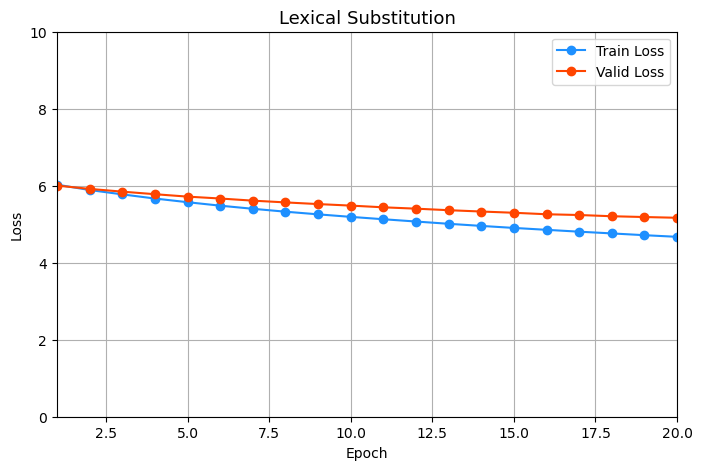

Source Sentence:  이별을 하고야 후회를 하네
Model Prediction:  ['잘', '찾아보세요세요세요세요세요세요세요세요세요세요세요세요보세요요보세요요보세요요보세요세요보세요', '거예요', '거예요', '거예요!']
Real:  ['그', '순간에는', '보이지', '않는', '것들이', '많지요.']
Score: 0.000000



0

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# x축(epoch)
epochs = range(1, len(train_loss_history_kss) + 1)

# loss plot
ax.plot(epochs, train_loss_history_kss, label='Train Loss',marker='o',color='dodgerblue')
ax.plot(epochs, valid_loss_history_kss, label='Valid Loss',marker='o',color='orangered')

# 축 이름
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

# y축 범위
ax.set_ylim(0, 10)

# x축 범위
ax.set_xlim(1, len(epochs))
ax.grid()
# 범례
ax.legend()
ax.set_title('Lexical Substitution',fontsize=13)

plt.show()

# Q. 인덱스를 바꿔가며 테스트해 보세요
test_idx = 0

eval_bleu_single(
    transformer,
    test_data['Q'].iloc[test_idx],
    test_data['A'].iloc[test_idx],
    tokenizer,
    tokenizer
)

In [41]:
belu_lexical=eval_bleu(
    transformer,
    test_data['Q'].tolist(),
    test_data['A'].tolist(),
    tokenizer,
    tokenizer,
    verbose=False
)

100%|██████████| 1183/1183 [02:06<00:00,  9.32it/s]

Num of Sample: 1183
Total Score: 0.002552782793771393


- kss를 사용하여 data augmentation 을 수행 후, loss는 수렴하는 것을 볼 수 있었으나 실제 model prediction 한 값들을 보거나 bleu score를 보더라도 성능이 좋다고는 일단 생각되지 않음

In [77]:


def evaluate2(sentence, model, tokenizer, max_len=30):

    model.eval()

    # 문장 전처리
    sentence = preprocess_ko(sentence)

    # token id 변환
    src_ids = tokenizer.encode_as_ids(sentence)

    # 길이 제한
    src_ids = src_ids[:max_len]

    # padding
    src_ids = src_ids + [0] * (max_len - len(src_ids))

    # tensor 변환
    enc_input = torch.LongTensor([src_ids]).to(device)

    # decoder 시작 token
    dec_input = torch.LongTensor([[1]]).to(device)

    with torch.no_grad():

        # mask 생성
        enc_mask = create_padding_mask(enc_input, enc_input)
        dec_mask = create_padding_mask(dec_input, dec_input)
        dec_enc_mask = create_padding_mask(dec_input, enc_input)

        # transformer forward
        logits, enc_attns, dec_attns, dec_enc_attns = model(
            enc_input,
            dec_input,
            enc_mask,
            dec_enc_mask,
            dec_mask
        )

    return sentence, enc_attns, dec_attns, dec_enc_attns
# attention map을 시각화

import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention(attention, tokens, layer=0, head=0):

    # attention map 추출
    attn_map = attention[layer][0, head].detach().cpu().numpy()

    # figure 생성
    fig, ax = plt.subplots(figsize=(8, 8))

    # heatmap
    sns.heatmap(
        attn_map,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='viridis',
        square=True,
        ax=ax
    )

    # 축 이름
    ax.set_xlabel("Key")
    ax.set_ylabel("Query")

    # -----------------------------
    # 한글 폰트 적용
    # -----------------------------
    ax.set_xticklabels(
        tokens,
        fontproperties=fontprop,
        rotation=45
    )

    ax.set_yticklabels(
        tokens,
        fontproperties=fontprop,
        rotation=0
    )

    plt.show()
    
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate2(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)
    
def create_padding_mask(q, k, pad_id=0):

    """
    q : query tensor
        shape = [batch_size, q_len]

    k : key tensor
        shape = [batch_size, k_len]

    return:
        attention mask
        shape = [batch_size, 1, q_len, k_len]
    """

    batch_size, q_len = q.size()
    batch_size, k_len = k.size()

    # padding 위치 찾기
    pad_mask = (k == pad_id)

    # shape 변환
    pad_mask = pad_mask.unsqueeze(1).unsqueeze(2)

    # q_len 방향으로 expand
    pad_mask = pad_mask.expand(batch_size, 1, q_len, k_len)

    return pad_mask

In [65]:
import logging
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
# !sudo apt-get install -y fonts-nanum
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")


설정된 폰트: NanumBarunGothic


/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45720 (\N{HANGUL SYLLABLE NEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50472 (\N{HANGUL SYLLABLE SSI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 46412 (\N{HANGUL SYLLABLE DDAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/

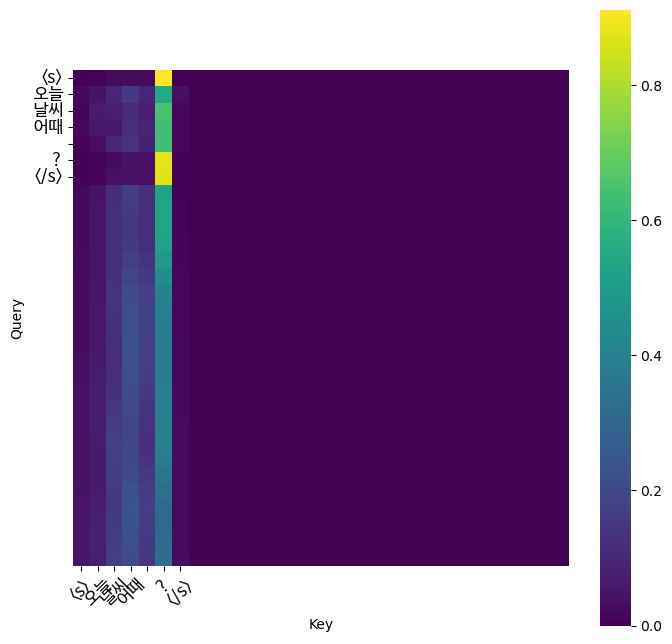

In [67]:
sentence = "오늘 날씨 어때 ?"

sentence, enc_attns, dec_attns, dec_enc_attns = evaluate2(
    sentence,
    transformer,
    tokenizer
)
tokens = tokenizer.encode_as_pieces(sentence)

plot_attention(
    enc_attns,
    tokens,
    layer=0,
    head=0
)

- 결과가 이상함 : ?를 제일 많이 보고 있음

### **(2) TF-IDF기반 Augmentation**

In [70]:
# ============================================
# TF-IDF 기반 한국어 Data Augmentation
# Fast Lexical Substitution Version
# ============================================

# 설치 필요 시
# !pip install konlpy
# !pip install scikit-learn

import random
import pandas as pd

from tqdm import tqdm
from konlpy.tag import Okt

from sklearn.feature_extraction.text import TfidfVectorizer


# ============================================
# 1. 형태소 분석기
# ============================================

okt = Okt()


# ============================================
# 2. 한국어 토큰화 함수
# ============================================

def tokenize_ko(sentence):

    tokens = okt.morphs(sentence)

    return tokens


# ============================================
# 3. TF-IDF 학습용 문장 corpus
# ============================================

corpus = list(train_data['Q']) + list(train_data['A'])


# ============================================
# 4. TF-IDF Vectorizer 학습
# ============================================

vectorizer = TfidfVectorizer(
    tokenizer=tokenize_ko,
    max_features=5000,
    token_pattern=None
)

tfidf_matrix = vectorizer.fit_transform(corpus)

# vocabulary 추출
vocab = vectorizer.get_feature_names_out()

# 단어별 idf score 저장
idf_scores = dict(
    zip(
        vectorizer.get_feature_names_out(),
        vectorizer.idf_
    )
)


# ============================================
# 5. 빠른 TF-IDF 기반 유사 단어 탐색
# ============================================

def get_similar_word_fast(word):

    # vocab에 없으면 그대로 반환
    if word not in vocab:
        return word

    try:

        target_idf = idf_scores[word]

        # IDF 값이 비슷한 단어 후보
        similar_candidates = [
            vocab_word
            for vocab_word in vocab
            if (
                vocab_word != word and
                abs(idf_scores[vocab_word] - target_idf) < 0.1
            )
        ]

        # 후보 없으면 원문 반환
        if len(similar_candidates) == 0:
            return word

        # 랜덤 선택
        similar_word = random.choice(similar_candidates)

        return similar_word

    except:
        return word


# ============================================
# 6. TF-IDF 기반 Lexical Substitution
# ============================================

def lexical_substitution_tfidf(sentence):

    # 형태소 토큰화
    tokens = tokenize_ko(sentence)

    # 치환 가능한 단어 후보
    candidate_tokens = [
        tok for tok in tokens
        if tok in vocab
    ]

    # 후보 없으면 원문 반환
    if len(candidate_tokens) == 0:
        return sentence

    # 랜덤 단어 선택
    selected_token = random.choice(candidate_tokens)

    # 빠른 유사 단어 탐색
    similar_word = get_similar_word_fast(selected_token)

    # 동일 단어면 원문 반환
    if similar_word == selected_token:
        return sentence

    # 단어 1개만 치환
    new_sentence = sentence.replace(
        selected_token,
        similar_word,
        1
    )

    return new_sentence


# ============================================
# 7. Data Augmentation
# ============================================

AUG_REPEAT = 3

augmented_q_tfidf = []
augmented_a_tfidf = []

for q, a in tqdm(
    zip(train_data['Q'], train_data['A']),
    total=len(train_data)
):

    # 원본 pair 추가
    augmented_q_tfidf.append(q)
    augmented_a_tfidf.append(a)

    # augmentation 반복
    for _ in range(AUG_REPEAT):

        new_q = lexical_substitution_tfidf(q)

        augmented_q_tfidf.append(new_q)

        # 답변은 그대로 유지
        augmented_a_tfidf.append(a)


# ============================================
# 8. DataFrame 생성
# ============================================

augmented_data_tfidf = pd.DataFrame({
    'Q': augmented_q_tfidf,
    'A': augmented_a_tfidf
})


# ============================================
# 9. 결과 확인
# ============================================

print("원본 데이터 개수 :", len(train_data))
print("증강 데이터 개수 :", len(augmented_data_tfidf))

print("\n===== 증강 예시 =====")

for i in range(5):

    print("원본 Q :", augmented_q_tfidf[i*2])
    print("증강 Q :", augmented_q_tfidf[i*2+1])
    print()

100%|██████████| 9458/9458 [01:33<00:00, 101.21it/s]

원본 데이터 개수 : 9458
증강 데이터 개수 : 37832

===== 증강 예시 =====
원본 Q : 환승당했다는 여자입니다.
증강 Q : 환승당했다는 또입니다.

원본 Q : 환승당했다는 정리입니다.
증강 Q : 환승당했다는 여자입니다.

원본 Q : 친구들이랑 가기 좋은 곳
증강 Q : 친구들이랑 가기 좀 곳

원본 Q : 좀들이랑 가기 좋은 곳
증강 Q : 친구들이랑 오는 좋은 곳

원본 Q : 나 좀 내버려 두면 좋겠어
증강 Q : 안 좀 내버려 두면 좋겠어



In [72]:
enc_corpus_tfidf = make_corpus(augmented_q_tfidf, tokenizer)
dec_corpus_tfidf = make_corpus(augmented_a_tfidf, tokenizer)


enc_ndarray_tfidf = pad_sequences_custom(enc_corpus_tfidf, max_len=ENCODER_MAX_LEN, pad_value=0)
dec_ndarray_tfidf = pad_sequences_custom(dec_corpus_tfidf, max_len=DECODER_MAX_LEN, pad_value=0)

print(enc_ndarray_tfidf.shape)  # 예) [batch_size, 50]
print(dec_ndarray_tfidf.shape)  # 예) [batch_size, 50]
print("슝=3")

# ============================================
# Train Tensor
# ============================================

train_enc_tensor_tfidf = torch.LongTensor(
    enc_ndarray_tfidf
)

train_dec_tensor_tfidf = torch.LongTensor(
    dec_ndarray_tfidf
)


# ============================================
# Train Dataset
# ============================================

train_dataset_tfidf = TensorDataset(
    train_enc_tensor_tfidf,
    train_dec_tensor_tfidf
)


# ============================================
# Train DataLoader
# ============================================

train_dataloader_tfidf = DataLoader(
    train_dataset_tfidf,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)
# =========================
# Validation
# =========================

# token id 변환
valid_enc_corpus_tfidf = make_corpus(valid_data['Q'], tokenizer)
valid_dec_corpus_tfidf = make_corpus(valid_data['A'], tokenizer)

# padding
valid_enc_ndarray_tfidf = pad_sequences_custom(
    valid_enc_corpus_tfidf,
    max_len=ENCODER_MAX_LEN,
    pad_value=0
)

valid_dec_ndarray_tfidf = pad_sequences_custom(
    valid_dec_corpus_tfidf,
    max_len=DECODER_MAX_LEN,
    pad_value=0
)

# tensor 변환
valid_enc_tensor_tfidf = torch.LongTensor(valid_enc_ndarray_tfidf)
valid_dec_tensor_tfidf = torch.LongTensor(valid_dec_ndarray_tfidf)

# dataset
valid_dataset_tfidf = TensorDataset(
    valid_enc_tensor_tfidf,
    valid_dec_tensor_tfidf
)

# dataloader
valid_dataloader_tfidf = DataLoader(
    valid_dataset_tfidf,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)


# =========================
# Test
# =========================

test_enc_corpus_tfidf = make_corpus(test_data['Q'], tokenizer)
test_dec_corpus_tfidf = make_corpus(test_data['A'], tokenizer)

test_enc_ndarray_tfidf = pad_sequences_custom(
    test_enc_corpus_tfidf,
    max_len=ENCODER_MAX_LEN,
    pad_value=0
)

test_dec_ndarray_tfidf = pad_sequences_custom(
    test_dec_corpus_tfidf,
    max_len=DECODER_MAX_LEN,
    pad_value=0
)

test_enc_tensor_tfidf = torch.LongTensor(test_enc_ndarray_tfidf)
test_dec_tensor_tfidf = torch.LongTensor(test_dec_ndarray_tfidf)

test_dataset_tfidf = TensorDataset(
    test_enc_tensor_tfidf,
    test_dec_tensor_tfidf
)

test_dataloader_tfidf = DataLoader(
    test_dataset_tfidf,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)



100%|██████████| 37832/37832 [00:00<00:00, 148081.04it/s]


torch.Size([37832, 13])
torch.Size([37832, 14])
슝=3


100%|██████████| 1183/1183 [00:00<00:00, 138124.92it/s]


In [73]:

# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer_tfidf = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=False,
    shared_emb=True)

transformer_tfidf= transformer_tfidf.to(device)

d_model = 512


# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer_tfidf = torch.optim.Adam(transformer_tfidf.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

슝=3


In [74]:
train_loss_history_tfidf, valid_loss_history_tfidf = train_model(
    transformer_tfidf,
    train_dataloader_tfidf,
    valid_dataloader_tfidf,
    optimizer_tfidf,
    EPOCHS=20
)

[Epoch 1/20] Train Loss: 9.3589 | Valid Loss: 9.2350
[Epoch 2/20] Train Loss: 9.3606 | Valid Loss: 9.2350
[Epoch 3/20] Train Loss: 9.3593 | Valid Loss: 9.2350
[Epoch 4/20] Train Loss: 9.3592 | Valid Loss: 9.2350
[Epoch 5/20] Train Loss: 9.3583 | Valid Loss: 9.2350
[Epoch 6/20] Train Loss: 9.3589 | Valid Loss: 9.2350
[Epoch 7/20] Train Loss: 9.3607 | Valid Loss: 9.2350
[Epoch 8/20] Train Loss: 9.3601 | Valid Loss: 9.2350
[Epoch 9/20] Train Loss: 9.3577 | Valid Loss: 9.2350
[Epoch 10/20] Train Loss: 9.3589 | Valid Loss: 9.2350
[Epoch 11/20] Train Loss: 9.3610 | Valid Loss: 9.2350
[Epoch 12/20] Train Loss: 9.3599 | Valid Loss: 9.2350
[Epoch 13/20] Train Loss: 9.3615 | Valid Loss: 9.2350
[Epoch 14/20] Train Loss: 9.3588 | Valid Loss: 9.2350
[Epoch 15/20] Train Loss: 9.3575 | Valid Loss: 9.2350
[Epoch 16/20] Train Loss: 9.3618 | Valid Loss: 9.2350
[Epoch 17/20] Train Loss: 9.3588 | Valid Loss: 9.2350
[Epoch 18/20] Train Loss: 9.3610 | Valid Loss: 9.2350
[Epoch 19/20] Train Loss: 9.3601 | Va

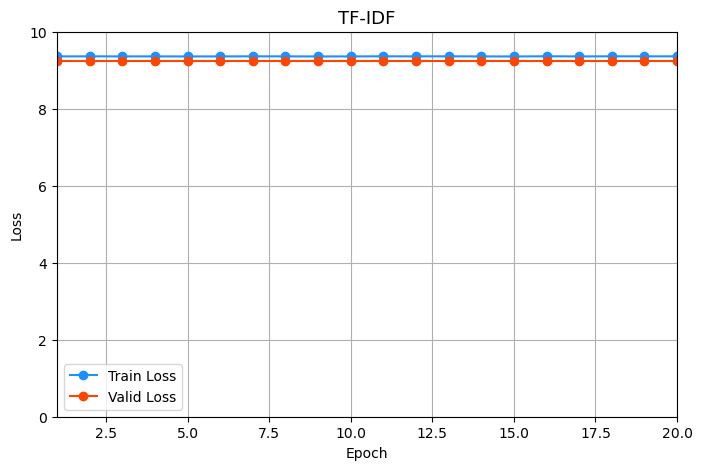

Source Sentence:  이별을 하고야 후회를 하네
Model Prediction:  ['간다워질거', '북', '붙잡아', '나네느리', '기울이', '싫은', '배고파', '가', '전화하기', '잔인', '잊을', '인', '구분짓한거', '지갑', '스타일이', '생각나는', '사람이었', '찌이라는', '넘었네', '떠나요', '없네', '공부해야어지지', '있다는데', '해요오래', '놓고', '무모룽가봅니다', '롱', '잘해줘서', '내보세요', '잘해줘서', '필요해보어지지', '잘해줘서', '첫사랑이', '복잡해', '까먹었다헤어졌네', '아울렛', '놀랐', '않을까요', '내려놓', '롱']
Real:  ['그', '순간에는', '보이지', '않는', '것들이', '많지요.']
Score: 0.000000



0

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# x축(epoch)
epochs = range(1, len(train_loss_history_tfidf) + 1)

# loss plot
ax.plot(epochs, train_loss_history_tfidf, label='Train Loss',marker='o',color='dodgerblue')
ax.plot(epochs, valid_loss_history_tfidf, label='Valid Loss',marker='o',color='orangered')

# 축 이름
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

# y축 범위
ax.set_ylim(0, 10)

# x축 범위
ax.set_xlim(1, len(epochs))
ax.grid()
# 범례
ax.legend()
ax.set_title('TF-IDF',fontsize=13)

plt.show()

# Q. 인덱스를 바꿔가며 테스트해 보세요
test_idx = 0

eval_bleu_single(
    transformer_tfidf,
    test_data['Q'].iloc[test_idx],
    test_data['A'].iloc[test_idx],
    tokenizer,
    tokenizer
)

In [105]:
bleu_tfidf=eval_bleu(
    transformer_tfidf,
    test_data['Q'].tolist(),
    test_data['A'].tolist(),
    tokenizer,
    tokenizer,
    verbose=False
)

100%|██████████| 1183/1183 [05:44<00:00,  3.44it/s]

Num of Sample: 1183
Total Score: 1.34769822277864e-05


/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45720 (\N{HANGUL SYLLABLE NEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50472 (\N{HANGUL SYLLABLE SSI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 46412 (\N{HANGUL SYLLABLE DDAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/

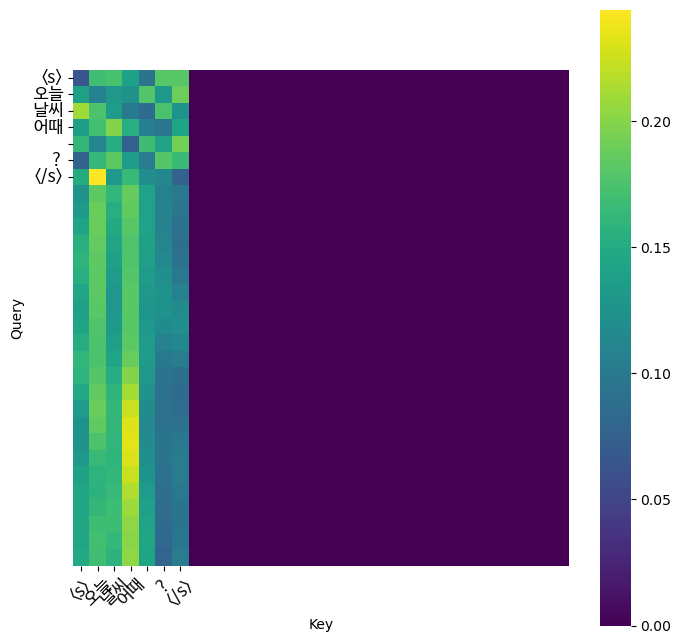

In [83]:
sentence = "오늘 날씨 어때 ?"

sentence_tfidf, enc_attns_tfidf, dec_attns_tfidf, dec_enc_attns_tfidf = evaluate2(
    sentence,
    transformer_tfidf,
    tokenizer
)
tokens_tfidf = tokenizer.encode_as_pieces(sentence)

plot_attention(
    enc_attns_tfidf,
    tokens_tfidf,
    layer=0,
    head=0
)

### **(3) Embedding 활용 기반**

In [88]:
# ============================================
# Embedding 기반 Lexical Substitution
# (Word2Vec / GloVe 방식)
# ============================================

import random
from tqdm import tqdm
from gensim.models import Word2Vec
from konlpy.tag import Okt

okt = Okt()

# ============================================
# 1. 형태소 토큰화
# ============================================

def tokenize_ko(sentence):

    # 형태소 분리
    tokens = okt.morphs(sentence)

    return tokens


# ============================================
# 2. Word2Vec 학습용 corpus 생성
# ============================================

tokenized_sentences = []

for sentence in train_data['Q']:
    tokenized_sentences.append(tokenize_ko(sentence))

for sentence in train_data['A']:
    tokenized_sentences.append(tokenize_ko(sentence))


# ============================================
# 3. Word2Vec 학습
# ============================================

w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)


# ============================================
# 4. Embedding 기반 단어 치환
# ============================================

def lexical_sub_embedding(sentence, wv):

    # 토큰화
    tokens = tokenize_ko(sentence)

    # embedding vocab 안에 존재하는 token만 사용
    valid_tokens = [
        tok for tok in tokens
        if tok in wv
    ]

    # 치환 가능한 단어가 없으면 원문 반환
    if len(valid_tokens) == 0:
        return sentence

    # 랜덤 단어 선택
    selected_tok = random.choice(valid_tokens)

    try:
        # 가장 유사한 단어 선택
        similar_word = wv.most_similar(selected_tok, topn=1)[0][0]

    except:
        return sentence

    # 선택된 단어 치환
    new_tokens = []

    replaced = False

    for tok in tokens:

        if tok == selected_tok and not replaced:
            new_tokens.append(similar_word)
            replaced = True

        else:
            new_tokens.append(tok)

    # 문장 복원
    new_sentence = " ".join(new_tokens)

    return new_sentence


# ============================================
# 5. Q/A augmentation
# ============================================

N_AUG = 3   # augmentation 횟수

augmented_q_embedding = []
augmented_a_embedding = []

for q, a in tqdm(
    zip(train_data['Q'], train_data['A']),
    total=len(train_data)
):

    # ----------------------------
    # 원본 데이터 추가
    # ----------------------------
    augmented_q_embedding.append(q)
    augmented_a_embedding.append(a)

    # ----------------------------
    # augmentation 여러 번 수행
    # ----------------------------
    for _ in range(N_AUG):

        # augmentation 생성
        new_q = lexical_sub_embedding(q, w2v_model.wv)
        new_a = lexical_sub_embedding(a, w2v_model.wv)

        # augmentation 추가
        augmented_q_embedding.append(new_q)
        augmented_a_embedding.append(new_a)


# ============================================
# 결과 확인
# ============================================

for i in range(5):

    print("원본 Q :", augmented_q_embedding[i*2])
    print("증강 Q :", augmented_q_embedding[i*2+1])

    print("원본 A :", augmented_a_embedding[i*2])
    print("증강 A :", augmented_a_embedding[i*2+1])

    print("=" * 50)

100%|██████████| 9458/9458 [02:50<00:00, 55.61it/s]

원본 Q : 환승당했다는 여자입니다.
증강 Q : , 당했다는 여자 입니다 .
원본 A : 사랑의 예의가 없는 사람이네요.
증강 A : 사랑 의 앞 가 없는 사람 이네 요 .
원본 Q : 환승 예정 여자 입니다 .
증강 Q : , 당했다는 여자 입니다 .
원본 A : 짝사랑 의 예의 가 없는 사람 이네 요 .
증강 A : 사랑 의 예의 가 없는 사람 이네 어떻게 .
원본 Q : 친구들이랑 가기 좋은 곳
증강 Q : 친구 들 이랑 , 좋은 곳
원본 A : 친구들과 함께면 어디든 좋아요.
증강 A : 친구 그 과 함께면 어디 든 좋아요 .
원본 Q : 친구 들 이랑 가기 일 곳
증강 Q : 친구 그 이랑 가기 좋은 곳
원본 A : 친구 들 에 함께면 어디 든 좋아요 .
증강 A : 친구 들 에 함께면 어디 든 좋아요 .
원본 Q : 나 좀 내버려 두면 좋겠어
증강 Q : 나 좀 내버려 두면 자꾸
원본 A : 많이 지쳤나봐요.
증강 A : 많이 지쳤나 하세요 .


In [89]:
# ============================================
# 9. 결과 확인
# ============================================

print("원본 데이터 개수 :", len(train_data))
print("증강 데이터 개수 :", len(augmented_a_embedding))


원본 데이터 개수 : 9458
증강 데이터 개수 : 37832


In [90]:
enc_corpus_embedding = make_corpus(augmented_q_embedding, tokenizer)
dec_corpus_embedding = make_corpus(augmented_a_embedding, tokenizer)


enc_ndarray_embedding = pad_sequences_custom(enc_corpus_embedding, max_len=ENCODER_MAX_LEN, pad_value=0)
dec_ndarray_embedding = pad_sequences_custom(dec_corpus_embedding, max_len=DECODER_MAX_LEN, pad_value=0)

print(enc_ndarray_embedding.shape)  # 예) [batch_size, 50]
print(dec_ndarray_embedding.shape)  # 예) [batch_size, 50]
print("슝=3")

# ============================================
# Train Tensor
# ============================================

train_enc_tensor_embedding = torch.LongTensor(
    enc_ndarray_embedding
)

train_dec_tensor_embedding = torch.LongTensor(
    dec_ndarray_embedding
)


# ============================================
# Train Dataset
# ============================================

train_dataset_embedding = TensorDataset(
    train_enc_tensor_embedding,
    train_dec_tensor_embedding
)


# ============================================
# Train DataLoader
# ============================================

train_dataloader_embedding = DataLoader(
    train_dataset_embedding,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)
# =========================
# Validation
# =========================

# token id 변환
valid_enc_corpus_embedding = make_corpus(valid_data['Q'], tokenizer)
valid_dec_corpus_embedding = make_corpus(valid_data['A'], tokenizer)

# padding
valid_enc_ndarray_embedding = pad_sequences_custom(
    valid_enc_corpus_embedding,
    max_len=ENCODER_MAX_LEN,
    pad_value=0
)

valid_dec_ndarray_embedding = pad_sequences_custom(
    valid_dec_corpus_embedding,
    max_len=DECODER_MAX_LEN,
    pad_value=0
)

# tensor 변환
valid_enc_tensor_embedding = torch.LongTensor(valid_enc_ndarray_embedding)
valid_dec_tensor_embedding = torch.LongTensor(valid_dec_ndarray_embedding)

# dataset
valid_dataset_embedding = TensorDataset(
    valid_enc_tensor_embedding,
    valid_dec_tensor_embedding
)

# dataloader
valid_dataloader_embedding = DataLoader(
    valid_dataset_embedding,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)


# =========================
# Test
# =========================

test_enc_corpus_embedding = make_corpus(test_data['Q'], tokenizer)
test_dec_corpus_embedding = make_corpus(test_data['A'], tokenizer)

test_enc_ndarray_embedding = pad_sequences_custom(
    test_enc_corpus_embedding,
    max_len=ENCODER_MAX_LEN,
    pad_value=0
)

test_dec_ndarray_embedding = pad_sequences_custom(
    test_dec_corpus_embedding,
    max_len=DECODER_MAX_LEN,
    pad_value=0
)

test_enc_tensor_embedding = torch.LongTensor(test_enc_ndarray_embedding)
test_dec_tensor_embedding = torch.LongTensor(test_dec_ndarray_embedding)

test_dataset_embedding = TensorDataset(
    test_enc_tensor_embedding,
    test_dec_tensor_embedding
)

test_dataloader_embedding = DataLoader(
    test_dataset_embedding,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)



100%|██████████| 37832/37832 [00:00<00:00, 127746.60it/s]


torch.Size([37832, 13])
torch.Size([37832, 14])
슝=3


100%|██████████| 1183/1183 [00:00<00:00, 138255.78it/s]


In [91]:

# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer_embedding = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=False,
    shared_emb=True)

transformer_embedding= transformer_embedding.to(device)

d_model = 512


# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer_embedding = torch.optim.Adam(transformer_embedding.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

슝=3


In [93]:
train_loss_history_embedding, valid_loss_history_embedding = train_model(
    transformer_embedding,
    train_dataloader_embedding,
    valid_dataloader_embedding,
    optimizer_embedding,
    EPOCHS=20
)

[Epoch 1/20] Train Loss: 6.8881 | Valid Loss: 7.0258
[Epoch 2/20] Train Loss: 5.7610 | Valid Loss: 6.6393
[Epoch 3/20] Train Loss: 5.4639 | Valid Loss: 6.4948
[Epoch 4/20] Train Loss: 5.3150 | Valid Loss: 6.3970
[Epoch 5/20] Train Loss: 5.2136 | Valid Loss: 6.3240
[Epoch 6/20] Train Loss: 5.1292 | Valid Loss: 6.2593
[Epoch 7/20] Train Loss: 5.0568 | Valid Loss: 6.1995
[Epoch 8/20] Train Loss: 4.9932 | Valid Loss: 6.1456
[Epoch 9/20] Train Loss: 4.9329 | Valid Loss: 6.0953
[Epoch 10/20] Train Loss: 4.8778 | Valid Loss: 6.0405
[Epoch 11/20] Train Loss: 4.8331 | Valid Loss: 5.9914
[Epoch 12/20] Train Loss: 4.7855 | Valid Loss: 5.9432
[Epoch 13/20] Train Loss: 4.7422 | Valid Loss: 5.9163
[Epoch 14/20] Train Loss: 4.7074 | Valid Loss: 5.8766
[Epoch 15/20] Train Loss: 4.6664 | Valid Loss: 5.8345
[Epoch 16/20] Train Loss: 4.6333 | Valid Loss: 5.8169
[Epoch 17/20] Train Loss: 4.5976 | Valid Loss: 5.7664
[Epoch 18/20] Train Loss: 4.5638 | Valid Loss: 5.7403
[Epoch 19/20] Train Loss: 4.5341 | Va

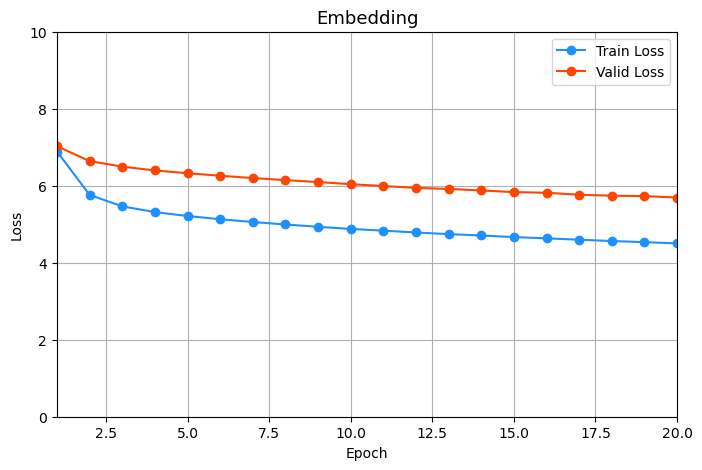

Source Sentence:  이별을 하고야 후회를 하네
Model Prediction:  ['의', '을', '해보세요', '봐요', '을', '해보세요', '을', '해보세요', '을', '해보세요', '을', '해보세요', '을', '해보세요', '을', '해보세요', '을', '해보세요', '을', '해보세요', '을', '해보세요', '을', '해보세요', '을', '해보세요', '을', '해보세요', '을', '해보세요', '일']
Real:  ['그', '순간에는', '보이지', '않는', '것들이', '많지요.']
Score: 0.000000



0

In [94]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# x축(epoch)
epochs = range(1, len(train_loss_history_embedding) + 1)

# loss plot
ax.plot(epochs, train_loss_history_embedding, label='Train Loss',marker='o',color='dodgerblue')
ax.plot(epochs, valid_loss_history_embedding, label='Valid Loss',marker='o',color='orangered')

# 축 이름
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

# y축 범위
ax.set_ylim(0, 10)

# x축 범위
ax.set_xlim(1, len(epochs))
ax.grid()
# 범례
ax.legend()
ax.set_title('Embedding',fontsize=13)

plt.show()

# Q. 인덱스를 바꿔가며 테스트해 보세요
test_idx = 0

eval_bleu_single(
    transformer_embedding,
    test_data['Q'].iloc[test_idx],
    test_data['A'].iloc[test_idx],
    tokenizer,
    tokenizer
)

In [95]:
bleu_embedding=eval_bleu(
    transformer_embedding,
    test_data['Q'].tolist(),
    test_data['A'].tolist(),
    tokenizer,
    tokenizer,
    verbose=False
)

100%|██████████| 1183/1183 [05:45<00:00,  3.42it/s]

Num of Sample: 1183
Total Score: 0.0003189415039485993


/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45720 (\N{HANGUL SYLLABLE NEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50472 (\N{HANGUL SYLLABLE SSI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 46412 (\N{HANGUL SYLLABLE DDAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/

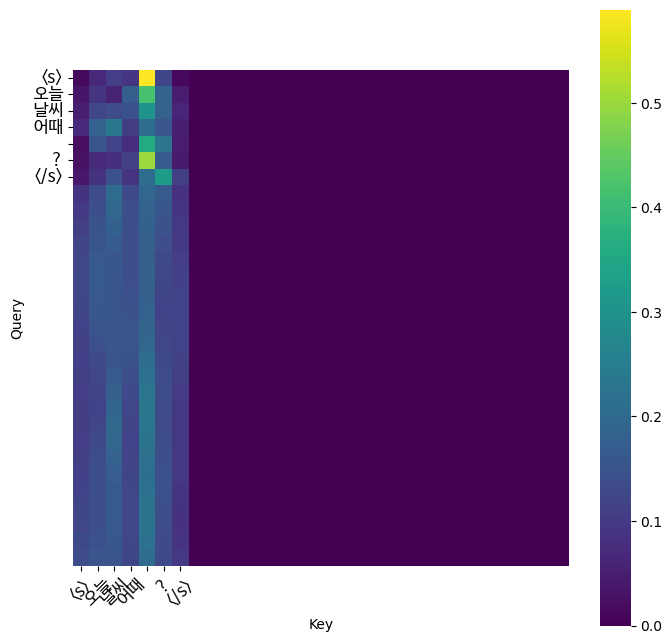

In [96]:
sentence = "오늘 날씨 어때 ?"

sentence_embedding, enc_attns_embedding, dec_attns_embedding, dec_enc_attns_embedding = evaluate2(
    sentence,
    transformer_embedding,
    tokenizer
)
tokens_embedding = tokenizer.encode_as_pieces(sentence)

plot_attention(
    enc_attns_embedding,
    tokens_embedding,
    layer=0,
    head=0
)

### **Original**

In [97]:
# ============================================
# Original Dataset (No Augmentation)
# ============================================

# 원본 데이터 그대로 사용
original_q = list(train_data['Q'])
original_a = list(train_data['A'])

print("원본 데이터 개수 :", len(original_q))


# ============================================
# Tokenization
# ============================================

enc_corpus_origin = make_corpus(
    original_q,
    tokenizer
)

dec_corpus_origin = make_corpus(
    original_a,
    tokenizer
)


# ============================================
# Padding
# ============================================

enc_ndarray_origin = pad_sequences_custom(
    enc_corpus_origin,
    max_len=ENCODER_MAX_LEN,
    pad_value=0
)

dec_ndarray_origin = pad_sequences_custom(
    dec_corpus_origin,
    max_len=DECODER_MAX_LEN,
    pad_value=0
)

print(enc_ndarray_origin.shape)
print(dec_ndarray_origin.shape)


# ============================================
# Tensor 변환
# ============================================

train_enc_tensor_origin = torch.LongTensor(
    enc_ndarray_origin
)

train_dec_tensor_origin = torch.LongTensor(
    dec_ndarray_origin
)


# ============================================
# Dataset 생성
# ============================================

train_dataset_origin = TensorDataset(
    train_enc_tensor_origin,
    train_dec_tensor_origin
)


# ============================================
# DataLoader 생성
# ============================================

train_dataloader_origin = DataLoader(
    train_dataset_origin,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)


# ============================================
# Validation
# ============================================

valid_enc_corpus_origin = make_corpus(
    valid_data['Q'],
    tokenizer
)

valid_dec_corpus_origin = make_corpus(
    valid_data['A'],
    tokenizer
)

valid_enc_ndarray_origin = pad_sequences_custom(
    valid_enc_corpus_origin,
    max_len=ENCODER_MAX_LEN,
    pad_value=0
)

valid_dec_ndarray_origin = pad_sequences_custom(
    valid_dec_corpus_origin,
    max_len=DECODER_MAX_LEN,
    pad_value=0
)

valid_enc_tensor_origin = torch.LongTensor(
    valid_enc_ndarray_origin
)

valid_dec_tensor_origin = torch.LongTensor(
    valid_dec_ndarray_origin
)

valid_dataset_origin = TensorDataset(
    valid_enc_tensor_origin,
    valid_dec_tensor_origin
)

valid_dataloader_origin = DataLoader(
    valid_dataset_origin,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)


# ============================================
# Test
# ============================================

test_enc_corpus_origin = make_corpus(
    test_data['Q'],
    tokenizer
)

test_dec_corpus_origin = make_corpus(
    test_data['A'],
    tokenizer
)

test_enc_ndarray_origin = pad_sequences_custom(
    test_enc_corpus_origin,
    max_len=ENCODER_MAX_LEN,
    pad_value=0
)

test_dec_ndarray_origin = pad_sequences_custom(
    test_dec_corpus_origin,
    max_len=DECODER_MAX_LEN,
    pad_value=0
)

test_enc_tensor_origin = torch.LongTensor(
    test_enc_ndarray_origin
)

test_dec_tensor_origin = torch.LongTensor(
    test_dec_ndarray_origin
)

test_dataset_origin = TensorDataset(
    test_enc_tensor_origin,
    test_dec_tensor_origin
)

test_dataloader_origin = DataLoader(
    test_dataset_origin,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

원본 데이터 개수 : 9458


100%|██████████| 9458/9458 [00:00<00:00, 127077.32it/s]


torch.Size([9458, 13])
torch.Size([9458, 14])


100%|██████████| 1183/1183 [00:00<00:00, 126545.82it/s]


In [98]:

# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer_origin = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=False,
    shared_emb=True)

transformer_origin= transformer_origin.to(device)

d_model = 512


# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer_origin = torch.optim.Adam(transformer_origin.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

슝=3


In [99]:
train_loss_history_origin, valid_loss_history_origin = train_model(
    transformer_origin,
    train_dataloader_origin,
    valid_dataloader_origin,
    optimizer_origin,
    EPOCHS=20
)

[Epoch 1/20] Train Loss: 8.3746 | Valid Loss: 7.6294
[Epoch 2/20] Train Loss: 7.4753 | Valid Loss: 7.0993
[Epoch 3/20] Train Loss: 7.0548 | Valid Loss: 6.8140
[Epoch 4/20] Train Loss: 6.8010 | Valid Loss: 6.6258
[Epoch 5/20] Train Loss: 6.6259 | Valid Loss: 6.4911
[Epoch 6/20] Train Loss: 6.4906 | Valid Loss: 6.3865
[Epoch 7/20] Train Loss: 6.3885 | Valid Loss: 6.3091
[Epoch 8/20] Train Loss: 6.3072 | Valid Loss: 6.2432
[Epoch 9/20] Train Loss: 6.2374 | Valid Loss: 6.1900
[Epoch 10/20] Train Loss: 6.1786 | Valid Loss: 6.1485
[Epoch 11/20] Train Loss: 6.1274 | Valid Loss: 6.1094
[Epoch 12/20] Train Loss: 6.0833 | Valid Loss: 6.0772
[Epoch 13/20] Train Loss: 6.0386 | Valid Loss: 6.0463
[Epoch 14/20] Train Loss: 6.0059 | Valid Loss: 6.0216
[Epoch 15/20] Train Loss: 5.9703 | Valid Loss: 5.9947
[Epoch 16/20] Train Loss: 5.9318 | Valid Loss: 5.9716
[Epoch 17/20] Train Loss: 5.9026 | Valid Loss: 5.9467
[Epoch 18/20] Train Loss: 5.8700 | Valid Loss: 5.9308
[Epoch 19/20] Train Loss: 5.8378 | Va

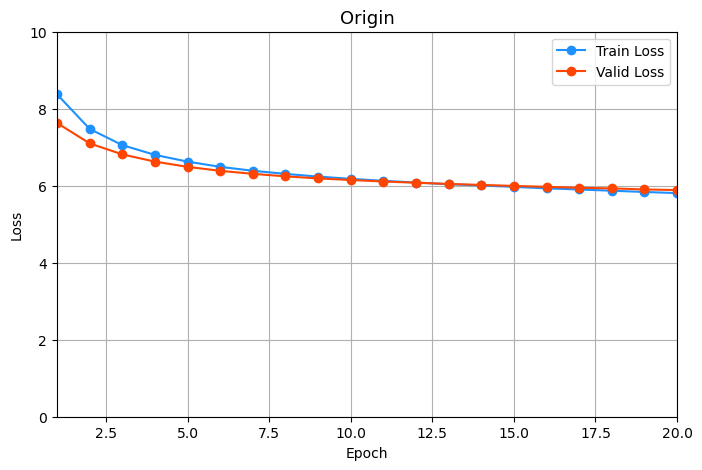

Source Sentence:  이별을 하고야 후회를 하네
Model Prediction:  ['그게게게게게게게게게고', '있어요', '돼요도', '돼요도', '돼요도', '돼요지', '않아요요보세요요보세요요요요보세요이보세요이보세요이네요죠요요요요요요요요요']
Real:  ['그', '순간에는', '보이지', '않는', '것들이', '많지요.']
Score: 0.000000



0

In [100]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# x축(epoch)
epochs = range(1, len(train_loss_history_origin) + 1)

# loss plot
ax.plot(epochs, train_loss_history_origin, label='Train Loss',marker='o',color='dodgerblue')
ax.plot(epochs, valid_loss_history_origin, label='Valid Loss',marker='o',color='orangered')

# 축 이름
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

# y축 범위
ax.set_ylim(0, 10)

# x축 범위
ax.set_xlim(1, len(epochs))
ax.grid()
# 범례
ax.legend()
ax.set_title('Origin',fontsize=13)

plt.show()

# Q. 인덱스를 바꿔가며 테스트해 보세요
test_idx = 0

eval_bleu_single(
    transformer_origin,
    test_data['Q'].iloc[test_idx],
    test_data['A'].iloc[test_idx],
    tokenizer,
    tokenizer
)

In [104]:
bleu_origin=eval_bleu(
    transformer_origin,
    test_data['Q'].tolist(),
    test_data['A'].tolist(),
    tokenizer,
    tokenizer,
    verbose=False
)

100%|██████████| 1183/1183 [05:37<00:00,  3.50it/s]

Num of Sample: 1183
Total Score: 0.00010338919055745272


/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45720 (\N{HANGUL SYLLABLE NEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50472 (\N{HANGUL SYLLABLE SSI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 46412 (\N{HANGUL SYLLABLE DDAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/

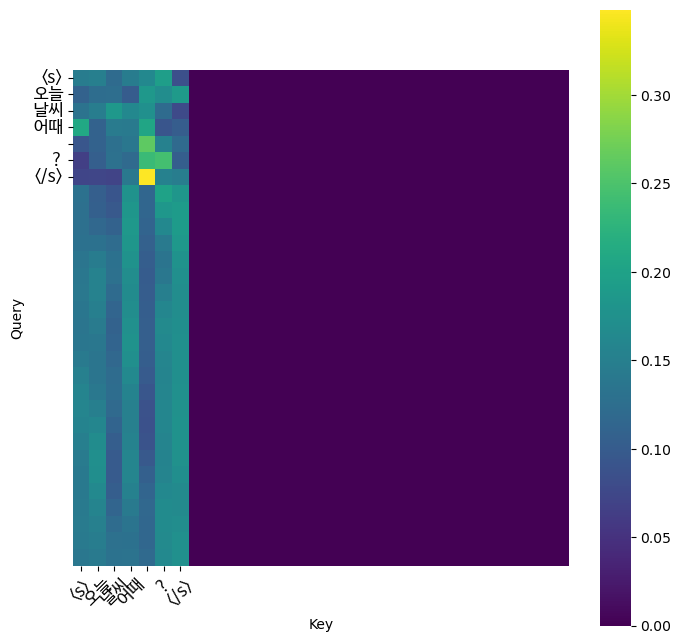

In [102]:
sentence = "오늘 날씨 어때 ?"

sentence_origin, enc_attns_origin, dec_attns_origin, dec_enc_attns_origin = evaluate2(
    sentence,
    transformer_origin,
    tokenizer
)
tokens_origin = tokenizer.encode_as_pieces(sentence)

plot_attention(
    enc_attns_origin,
    tokens_tfidf,
    layer=0,
    head=0
)

In [110]:
from IPython.display import Markdown, display

markdown_table = f"""
# BLEU Score Comparison

| Experiment | Augmentation Method | BLEU Score |
|---|---|---|
| Transformer-Lexical | Lexical Substitution | 0.0026 |
| Transformer-TFIDF | TF-IDF Based | 0.0000 |
| Transformer-Embedding | Embedding Based | 0.0032 |
| Transformer-Original | None | 0.0001 |
"""

display(Markdown(markdown_table))


# BLEU Score Comparison

| Experiment | Augmentation Method | BLEU Score |
|---|---|---|
| Transformer-Lexical | Lexical Substitution | 0.0026 |
| Transformer-TFIDF | TF-IDF Based | 0.0000 |
| Transformer-Embedding | Embedding Based | 0.0032 |
| Transformer-Original | None | 0.0001 |


## 회고
- chatbot에서 data augmentation 을 통한 결과 차이를 알아보고 attention map을 그리는 프로젝트를 수행했다
- 성능이 좋게 나오지 않는다 model prediction 값과 real이 전혀 공통점이 안보인다 -> 모델의 수정이 필요
- BLEU Score로 비교해 보았을 때 data augmentation 효과가 나타나고 있다
- Decoder 에 Beam Search 로 변경해서 동일한 실험을 수행해서 결과를 비교해보고 싶다 